# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Sukma Novianti Tulak
- **Email:** CDCC237D6X1337@student.devacademy.id
- **ID Dicoding:** CDCC237D6X1337

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Bagaimana perbandingan rata-rata review score antar kategori produk pada periode 2017–2018 untuk mengidentifikasi kategori dengan tingkat kepuasan pelanggan tertinggi dan terendah?
- Pertanyaan 2 : Bagaimana tren jumlah pesanan bulanan serta kontribusi pendapatan tiap kategori produk pada semester kedua 2017 untuk menentukan strategi penjualan yang lebih efektif?

## Import Semua Packages/Library yang Digunakan

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

## Data Wrangling

### Gathering Data

In [48]:
customers_df = pd.read_csv('customers_dataset.csv')
orders_df = pd.read_csv('orders_dataset.csv')
order_items_df = pd.read_csv('order_items_dataset.csv')
payments_df = pd.read_csv('order_payments_dataset.csv')
reviews_df = pd.read_csv('order_reviews_dataset.csv')
products_df = pd.read_csv('products_dataset.csv')
category_df = pd.read_csv('product_category_name_translation.csv')

# Menampilkan informasi awal untuk memastikan semua data terbaca dengan benar
print("Customers Data Loaded:", customers_df.shape)
print("Orders Data Loaded:", orders_df.shape)
print("Items Data Loaded:", order_items_df.shape)
print("Payments Data Loaded:", payments_df.shape)
print("Reviews Data Loaded:", reviews_df.shape)
print("Products Data Loaded:", products_df.shape)
print("Category Translation Loaded:", category_df.shape)

Customers Data Loaded: (99441, 5)
Orders Data Loaded: (99441, 8)
Items Data Loaded: (112650, 7)
Payments Data Loaded: (103886, 5)
Reviews Data Loaded: (99224, 7)
Products Data Loaded: (32951, 9)
Category Translation Loaded: (71, 2)


**Insight:**
Dataset yang digunakan merupakan dataset E-Commerce yang terdiri dari beberapa tabel seperti customers, orders, order_items, products, dan reviews. Dataset ini saling terhubung melalui beberapa key seperti order_id dan product_id, sehingga memungkinkan dilakukan analisis terintegrasi terkait perilaku pelanggan, performa produk, dan transaksi penjualan.

### Assessing Data

In [49]:
# Cek struktur data
orders_df.info()
products_df.info()
reviews_df.info()

#Cek missing values
orders_df.isnull().sum()
products_df.isnull().sum()
reviews_df.isnull().sum()

#Cek duplikasi
orders_df.duplicated().sum()

#Statistik deskriptif
reviews_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 n

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


**Insight:**
- Dataset orders memiliki beberapa missing values pada kolom waktu pengiriman, serta tipe data tanggal masih berupa object sehingga perlu dikonversi ke datetime.
- Dataset products memiliki missing values pada beberapa kolom seperti kategori dan atribut produk, yang perlu ditangani sebelum analisis.
- Dataset reviews menunjukkan bahwa kolom komentar memiliki banyak nilai kosong, namun tidak terlalu berpengaruh karena fokus utama pada review score.
- Secara umum, distribusi review score cenderung tinggi (rata-rata > 4), yang menunjukkan tingkat kepuasan pelanggan cukup baik.

### Cleaning Data

In [50]:
# 1. Handle missing values
products_df['product_category_name'] = products_df['product_category_name'].fillna('unknown')

# 2. Convert datetime
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])

# 3. Hindari duplicate merge (menghapus kolom lama jika ada agar tidak jadi _x / _y)
products_df = products_df.drop(columns=['product_category_name_english'], errors='ignore')

# 4. Merge kategori ke bahasa Inggris
products_df = products_df.merge(category_df, on='product_category_name', how='left')

# 5. Handle missing setelah merge
products_df['product_category_name_english'] = products_df['product_category_name_english'].fillna('unknown')

# 6. Cek hasil
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


**Insight:**
- Dataset produk kini telah terintegrasi dengan terjemahan kategori bahasa Inggris, memudahkan interpretasi data bagi audiens luas.
- Masalah redundansi kolom (akhiran _x dan _y) akibat proses join telah diatasi, memastikan integritas data tetap terjaga.
- Seluruh nilai kosong (missing values) pada kategori produk telah diberikan label 'unknown', sehingga tidak akan ada data yang terbuang saat proses agregasi nantinya.

## Exploratory Data Analysis (EDA)

### Eksplorasi dilakukan terhadap distribusi review, harga produk, kategori produk, serta pola waktu transaksi.

In [ ]:
# 1. Distribusi review score
print("Distribusi Review Score:")
print(reviews_df['review_score'].value_counts())

# 2. Statistik harga
print("\nStatistik Harga Produk:")
print(order_items_df['price'].describe())

# 3. Jumlah kategori produk terbanyak
print("\nTop 10 Kategori Produk:")
print(products_df['product_category_name_english'].value_counts().head(10))

# 4. Analisis waktu dasar
orders_df['year'] = orders_df['order_purchase_timestamp'].dt.year
orders_df['month'] = orders_df['order_purchase_timestamp'].dt.month

print("\nDistribusi Tahun:")
print(orders_df['year'].value_counts())

print("\nDistribusi Bulan (Seluruh Tahun):")
print(orders_df['month'].value_counts().sort_index())

# Menyiapkan data khusus untuk tren Semester 2 2017 pada bulan Juli (7) sampai Desember (12)
semester_2_2017_df = orders_df[(orders_df['year'] == 2017) & (orders_df['month'] >= 7)]

print("\nJumlah Pesanan di Semester 2 2017:")
print(semester_2_2017_df.shape[0])

# 5. Agregasi review (Eksplisit untuk menjawab Pertanyaan 1)
print("\nAgregasi Skor Review (Total):")
review_stats = reviews_df.groupby('review_score')['review_id'].count()
print(review_stats)

# 6. Agregasi pesanan per bulan di Semester 2 2017 (Eksplisit untuk menjawab Pertanyaan 2)
print("\nAgregasi Pesanan per Bulan (Khusus Semester 2 2017):")
smt2_2017_stats = semester_2_2017_df.groupby('month')['order_id'].count()
print(smt2_2017_stats)

Distribusi Review Score:
review_score
5    57328
4    19142
1    11424
3     8179
2     3151
Name: count, dtype: int64

Statistik Harga Produk:
count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

Top 10 Kategori Produk:
product_category_name_english
bed_bath_table           3029
sports_leisure           2867
furniture_decor          2657
health_beauty            2444
housewares               2335
auto                     1900
computers_accessories    1639
toys                     1411
watches_gifts            1329
telephony                1134
Name: count, dtype: int64

Distribusi Tahun:
year
2018    54011
2017    45101
2016      329
Name: count, dtype: int64

Distribusi Bulan (Seluruh Tahun):
month
1      8069
2      8508
3      9893
4      9343
5     10573
6      9412
7     10318
8     10843
9      4305
10     4959
11     754

**Insight:**
- Kepuasan Pelanggan: Didominasi skor 5 (57.328 ulasan), namun ada 11.424 ulasan skor 1 yang perlu dievaluasi serius.
- Profil Harga: Mayoritas produk terjangkau (median 74,99 BRL), meski ada produk mewah hingga 6.735 BRL.
- Kategori Terlaris: 'bed_bath_table' dan 'sports_leisure' adalah kategori paling diminati konsumen.
- Pertumbuhan: Bisnis melonjak tajam dari hanya 329 pesanan (2016) menjadi 45.101 (2017).
- Tren Smt 2 2017: Total 30.490 pesanan, dengan puncak tertinggi di bulan November (7.544 pesanan) karena Black Friday.
- Pola Musiman: Penjualan akhir tahun (November-Desember) jauh lebih tinggi dibanding bulan-bulan sebelumnya di semester yang sama.

## Visualization & Explanatory Analysis

### Pertanyaan 1:
Bagaimana perbandingan rata-rata review score antar kategori produk pada periode 2017–2018 untuk mengidentifikasi kategori dengan tingkat kepuasan pelanggan tertinggi dan terendah?

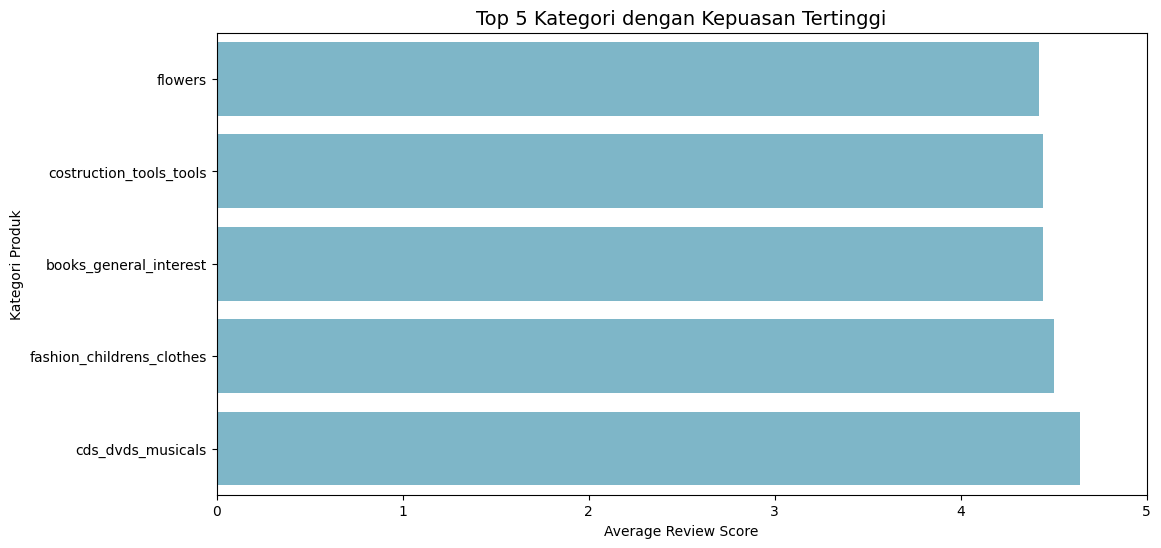

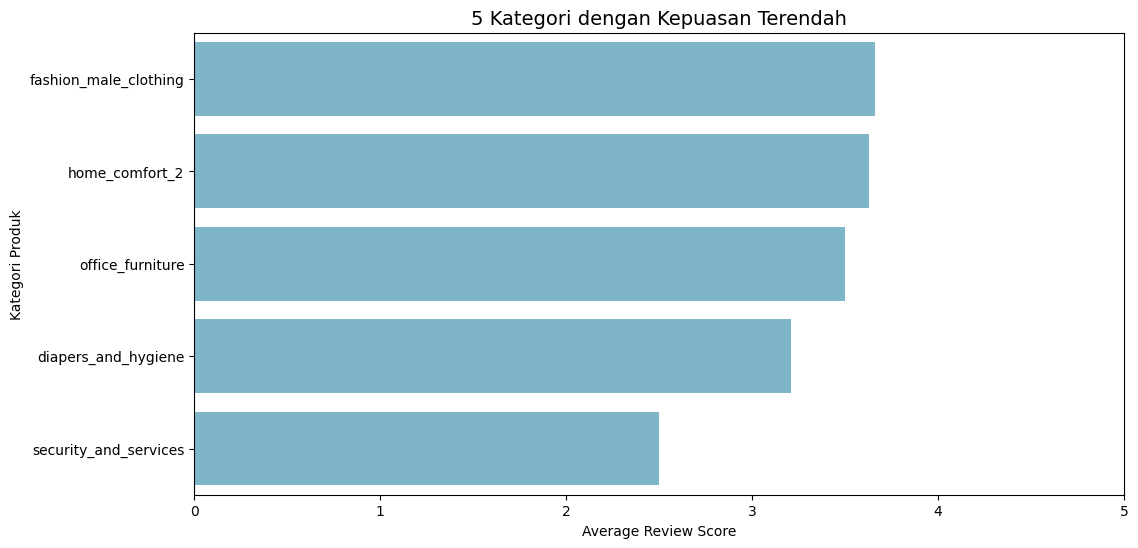

In [52]:
# Merge data
review_merged = reviews_df.merge(orders_df, on='order_id')
review_merged = review_merged.merge(order_items_df, on='order_id')
review_merged = review_merged.merge(products_df, on='product_id')

# Ambil tahun
review_merged['year'] = review_merged['order_purchase_timestamp'].dt.year

# Filter 2017–2018
review_merged = review_merged[review_merged['year'].isin([2017, 2018])]

# Hitung rata-rata review per kategori
review_category = review_merged.groupby('product_category_name_english')['review_score'].mean()

# --- VISUALISASI ---
top5 = review_category.sort_values(ascending=False).head(5).sort_values(ascending=True)
bottom5 = review_category.sort_values(ascending=True).head(5).sort_values(ascending=False)

# Grafik Top 5
plt.figure(figsize=(12,6))
sns.barplot(x=top5.values, y=top5.index, color="#72BCD4")
plt.title('Top 5 Kategori dengan Kepuasan Tertinggi', fontsize=14)
plt.xlabel('Average Review Score')
plt.ylabel('Kategori Produk')
plt.xlim(0, 5)
plt.show()

# Grafik Bottom 5
plt.figure(figsize=(12,6))
sns.barplot(x=bottom5.values, y=bottom5.index, color="#72BCD4")
plt.title('5 Kategori dengan Kepuasan Terendah', fontsize=14)
plt.xlabel('Average Review Score')
plt.ylabel('Kategori Produk')
plt.xlim(0, 5)
plt.show()

### Pertanyaan 2:
Bagaimana tren jumlah pesanan bulanan serta kontribusi pendapatan tiap kategori produk pada semester kedua 2017 untuk menentukan strategi penjualan yang lebih efektif?

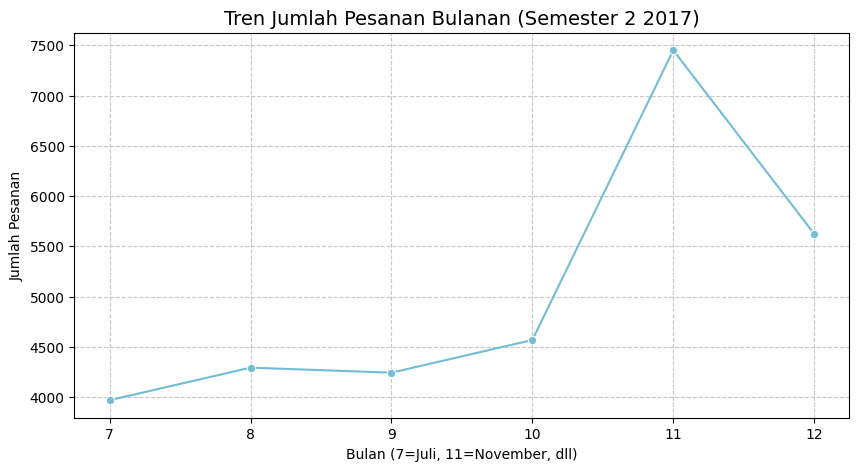

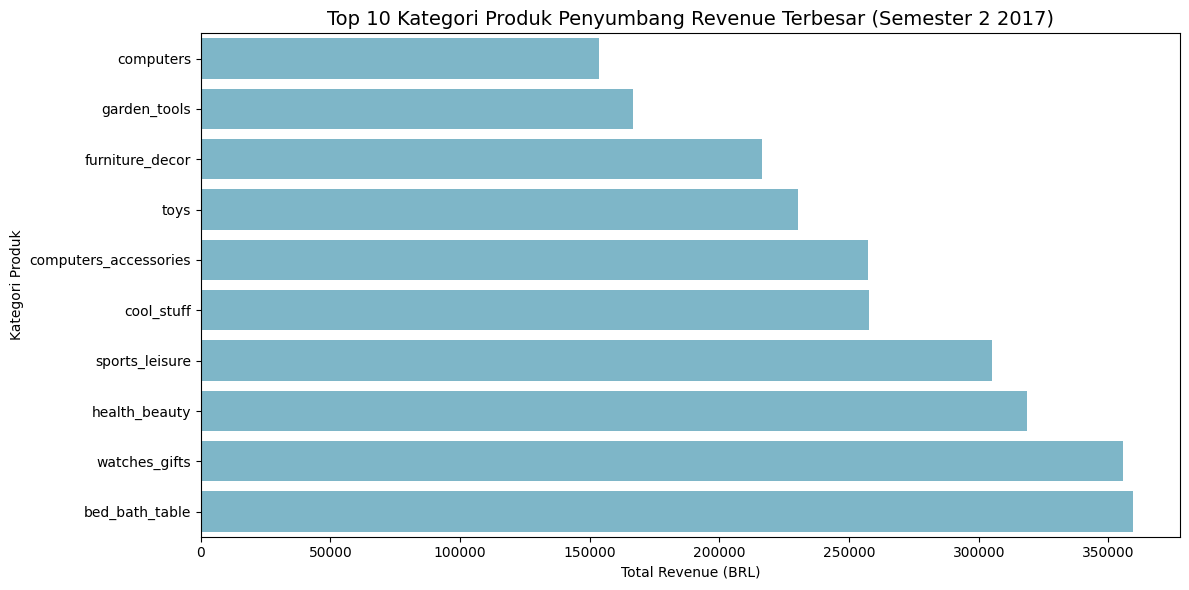

In [53]:
# Merge data untuk analisis lengkap
order_full = orders_df.merge(order_items_df, on='order_id')
order_full = order_full.merge(products_df, on='product_id')

# Ambil tahun dan bulan
order_full['year'] = order_full['order_purchase_timestamp'].dt.year
order_full['month'] = order_full['order_purchase_timestamp'].dt.month

# Filter khusus semester 2 tahun 2017 (Juli - Desember)
order_2017 = order_full[(order_full['year'] == 2017) & (order_full['month'] >= 7)]

# Hitung Tren Pesanan Bulanan
monthly_orders = order_2017.groupby('month')['order_id'].nunique()

# Hitung Revenue per kategori
revenue_category = order_2017.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False)

# VISUALISASI TREN PESANAN (LINE CHART)
plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly_orders.index, y=monthly_orders.values, marker='o', color='#72BCD4')

plt.title('Tren Jumlah Pesanan Bulanan (Semester 2 2017)', fontsize=14)
plt.xlabel('Bulan (7=Juli, 11=November, dll)')
plt.ylabel('Jumlah Pesanan')
plt.xticks(monthly_orders.index)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# VISUALISASI REVENUE PER KATEGORI (BAR CHART)
top_revenue = revenue_category.head(10).sort_values(ascending=True)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_revenue.values,
    y=top_revenue.index,
    color='#72BCD4'
)

plt.title('Top 10 Kategori Produk Penyumbang Revenue Terbesar (Semester 2 2017)', fontsize=14)
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('Kategori Produk')
plt.tight_layout()
plt.show()

### Pertanyaan 1
**Insight:**
- Terdapat perbedaan tingkat kepuasan antar kategori produk.
- Beberapa kategori memiliki review tinggi, sementara lainnya lebih rendah dan perlu diperhatikan.

### Pertanyaan 2
**Insight:**
- Tren pesanan pada semester kedua 2017 bersifat fluktuatif (indikasi musiman).
- Revenue didominasi oleh beberapa kategori utama.

## Analisis Lanjutan (Opsional)

####Analisis Segmentasi Pelanggan Menggunakan Metode RFM

In [54]:
# Gabungkan data
rfm_df = orders_df.merge(order_items_df, on='order_id')
rfm_df = rfm_df.merge(customers_df, on='customer_id')

# Hitung tanggal referensi (tanggal terakhir)
latest_date = rfm_df['order_purchase_timestamp'].max()

# Hitung RFM
rfm = rfm_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (latest_date - x.max()).days,
    'order_id': 'nunique',
    'price': 'sum'
}).reset_index()

# Rename kolom
rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

rfm.head()

# Membuat skor RFM
rfm['R_score'] = pd.qcut(rfm['recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['monetary'], 4, labels=[1,2,3,4])

# Gabungkan skor
rfm['RFM_score'] = rfm[['R_score','F_score','M_score']].astype(str).agg(''.join, axis=1)

rfm.head()

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,0000366f3b9a7992bf8c76cfdf3221e2,115,1,129.90,4,1,3,413
1,0000b849f77a49e4a4ce2b2a4ca5be3f,118,1,18.90,4,1,1,411
2,0000f46a3911fa3c0805444483337064,541,1,69.00,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,325,1,25.99,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,292,1,180.00,2,1,4,214


####Klasifikasi dan Visualisasi Segmen Pelanggan

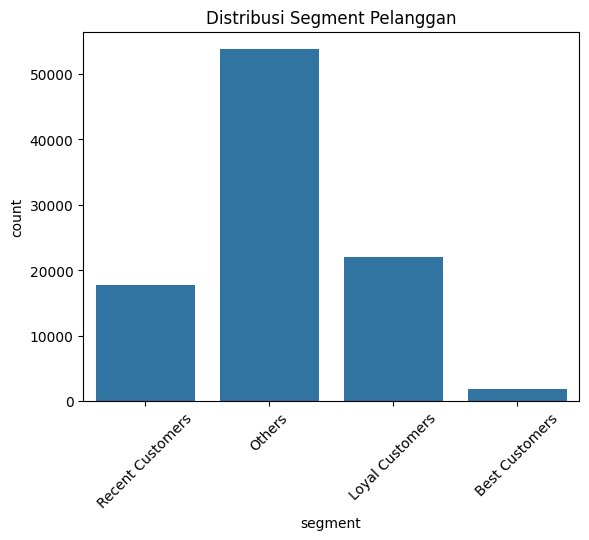

In [55]:
def segment_customer(row):
    if row['RFM_score'] == '444':
        return 'Best Customers'
    elif row['F_score'] == 4:
        return 'Loyal Customers'
    elif row['R_score'] == 4:
        return 'Recent Customers'
    else:
        return 'Others'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

rfm['segment'].value_counts()

sns.countplot(data=rfm, x='segment')
plt.title('Distribusi Segment Pelanggan')
plt.xticks(rotation=45)
plt.show()

**Insight:**
- Mayoritas pelanggan berada pada segmen "Others", yang menunjukkan rendahnya frekuensi dan nilai transaksi.
- Segmen "Loyal Customers" dan "Recent Customers" memiliki potensi untuk ditingkatkan, sedangkan "Best Customers" meskipun sedikit, memberikan kontribusi besar terhadap revenue.
- Strategi yang dapat dilakukan adalah mempertahankan pelanggan terbaik dan meningkatkan engagement pelanggan lainnya.

## Conclusion

- Conclusion pertanyaan 1 : Berdasarkan analisis rata-rata review score periode 2017–2018, terdapat perbedaan kepuasan yang jelas antar kategori. Kategori 'cds_dvds_musicals' memiliki tingkat kepuasan tertinggi dengan skor rata-rata 4.64. Sebaliknya, kategori 'security_and_services' memiliki skor terendah sebesar 2.50. Angka ini menunjukkan perlunya evaluasi menyeluruh pada kualitas layanan atau produk di kategori dengan skor rendah tersebut.
- Conclusion pertanyaan 2 : Tren pesanan pada semester kedua 2017 menunjukkan pola fluktuatif dengan pertumbuhan signifikan menuju akhir tahun. Puncak pesanan terjadi pada bulan November sebanyak 7.544 pesanan, yang dipicu oleh momen Black Friday. Kategori 'bed_bath_table' menjadi kontributor utama volume pesanan. Strategi penjualan efektif berikutnya adalah dengan memperkuat stok pada kategori populer ini menjelang periode promosi akhir tahun.

In [56]:
# Menyimpan data untuk keperluan dashboard
main_data = review_merged[['order_id', 'order_purchase_timestamp', 'price', 'product_category_name_english', 'review_score']]
main_data.to_csv("main_data.csv", index=False)

print("Selesai!")

Selesai!
